In [1]:
# loading libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# loading datasets

transactions = pd.read_csv('downloads/Retail_Data_Transactions.csv')
responses = pd.read_csv('downloads/Retail_Data_Response.csv')

In [3]:
# Displaying information for transactions dataset

print("Transactions Data Shape:", transactions.shape)
print("\nFirst 5 rows of transactions:")
print(transactions.head())
print("\nTransaction data info:")
transactions.info()

Transactions Data Shape: (125000, 3)

First 5 rows of transactions:
  customer_id trans_date  tran_amount
0      CS5295  11-Feb-13           35
1      CS4768  15-Mar-15           39
2      CS2122  26-Feb-13           52
3      CS1217  16-Nov-11           99
4      CS1850  20-Nov-13           78

Transaction data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   customer_id  125000 non-null  object
 1   trans_date   125000 non-null  object
 2   tran_amount  125000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.9+ MB


In [4]:
# Displaying information for responses dataset

print("Responses Data Shape:", responses.shape)
print("\nFirst 5 rows of responses:")
print(responses.head())
print("\nResponses data info:")
responses.info()

Responses Data Shape: (6884, 2)

First 5 rows of responses:
  customer_id  response
0      CS1112         0
1      CS1113         0
2      CS1114         1
3      CS1115         1
4      CS1116         1

Responses data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6884 entries, 0 to 6883
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  6884 non-null   object
 1   response     6884 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 107.7+ KB


In [5]:
# Renaming columns

transactions.rename(columns={'trans_date': 'transaction_date'}, inplace=True)

In [6]:
# Changing date format

transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date'],
    format='%d-%b-%y')

In [7]:
# Setting analysis date (1 day after last transaction)

analysis_date = transactions['transaction_date'].max() + timedelta(days=1)
print(f'Analysis Date: {analysis_date}')

Analysis Date: 2015-03-17 00:00:00


In [8]:
# Calculating RFM metrics

rfm_data = transactions.groupby('customer_id').agg({
    'transaction_date': lambda x: (analysis_date - x.max()).days,  # Recency
    'customer_id': 'count',  # Frequency
    'tran_amount': 'sum'  # Monetary
}).rename(columns={
    'transaction_date': 'Recency',
    'customer_id': 'Frequency',
    'tran_amount': 'Monetary'
}).reset_index()

print(f"\nUnique customers: {len(rfm_data)}")
print(rfm_data.head())


Unique customers: 6889
  customer_id  Recency  Frequency  Monetary
0      CS1112       62         15      1012
1      CS1113       36         20      1490
2      CS1114       33         19      1432
3      CS1115       12         22      1659
4      CS1116      204         13       857


In [9]:
# Creating RFM quartile scores

rfm_data['R_Score'] = pd.qcut(rfm_data['Recency'], 4, labels=[4, 3, 2, 1])
rfm_data['F_Score'] = pd.qcut(rfm_data['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm_data['M_Score'] = pd.qcut(rfm_data['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4])

In [10]:
# Combine scores

rfm_data['RFM_Score'] = rfm_data['R_Score'].astype(str) + rfm_data['F_Score'].astype(str) + rfm_data['M_Score'].astype(str)
print(rfm_data.head())

  customer_id  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0      CS1112       62         15      1012       2       2       2       222
1      CS1113       36         20      1490       3       3       3       333
2      CS1114       33         19      1432       3       3       3       333
3      CS1115       12         22      1659       4       3       4       434
4      CS1116      204         13       857       1       1       2       112


In [11]:
# Defining RFM segments

def get_segment(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 4:
        return 'Recent Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    elif row['R_Score'] <= 2:
        return 'Hibernating'
    else:
        return 'Potential Loyalists'

rfm_data['Segment'] = rfm_data.apply(get_segment, axis=1)
print (rfm_data.head())

  customer_id  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
0      CS1112       62         15      1012       2       2       2       222   
1      CS1113       36         20      1490       3       3       3       333   
2      CS1114       33         19      1432       3       3       3       333   
3      CS1115       12         22      1659       4       3       4       434   
4      CS1116      204         13       857       1       1       2       112   

           Segment  
0      Hibernating  
1  Loyal Customers  
2  Loyal Customers  
3  Loyal Customers  
4      Hibernating  


In [12]:
# Analyze segments

segment_summary = rfm_data.groupby('Segment').agg({
    'customer_id': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'customer_id': 'Count'}).sort_values('Count', ascending=False)

print("\nCustomer Segments Summary:")
print(segment_summary)


Customer Segments Summary:
                     Count     Recency  Frequency     Monetary
Segment                                                       
Hibernating           1995  156.046617  13.695739   802.292231
Loyal Customers       1500   27.654667  21.634000  1469.909333
At Risk               1448  115.228591  22.020028  1508.017956
Recent Customers       729   11.742112  14.408779   863.825789
Potential Loyalists    721   38.915395  14.246879   853.934813
Champions              496   10.993952  25.332661  1793.399194


In [13]:
# Preparing data for clustering

rfm_scaled = rfm_data[['Recency', 'Frequency', 'Monetary']].copy()

In [14]:
# Log transform to handle skewness

rfm_scaled['Recency'] = np.log1p(rfm_scaled['Recency'])
rfm_scaled['Frequency'] = np.log1p(rfm_scaled['Frequency'])
rfm_scaled['Monetary'] = np.log1p(rfm_scaled['Monetary'])

print (rfm_scaled.head())

    Recency  Frequency  Monetary
0  4.143135   2.772589  6.920672
1  3.610918   3.044522  7.307202
2  3.526361   2.995732  7.267525
3  2.564949   3.135494  7.414573
4  5.323010   2.639057  6.754604


In [15]:
# Standardizing features

scaler = StandardScaler()
rfm_scaled = pd.DataFrame(scaler.fit_transform(rfm_scaled), 
                          columns=['Recency', 'Frequency', 'Monetary'])

print (rfm_scaled)

       Recency  Frequency  Monetary
0     0.232145  -0.472131 -0.114796
1    -0.229685   0.451581  0.696465
2    -0.303060   0.285849  0.613190
3    -1.137323   0.760596  0.921817
4     1.255980  -0.925714 -0.463343
...        ...        ...       ...
6884  0.624355  -0.925714 -1.274365
6885  1.472175  -0.691357 -1.419684
6886  0.502199  -0.925714 -1.128362
6887  1.458876  -1.177445 -2.150719
6888 -0.854938  -0.925714 -1.458624

[6889 rows x 3 columns]


In [16]:
# Finding optimal number of clusters using Elbow Method

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

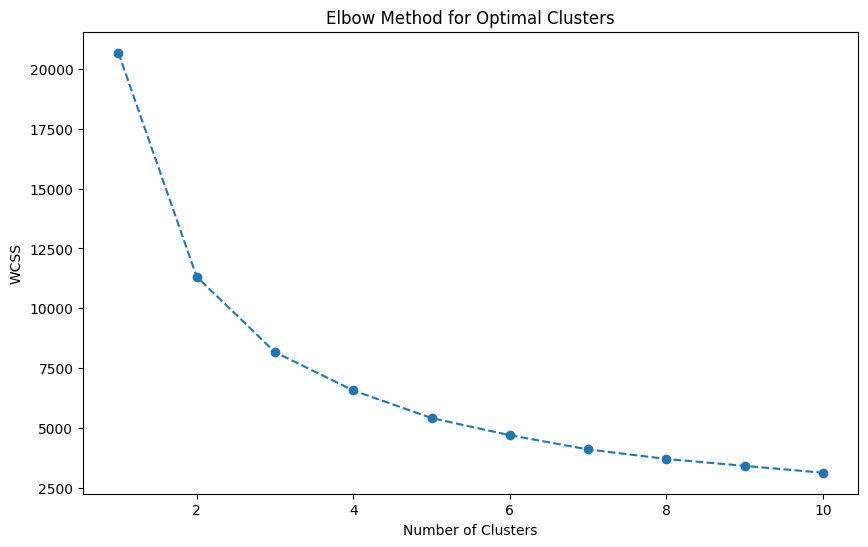

In [17]:
# Plotting Elbow Curve

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [20]:
# Applying K-Means with selected clusters (4)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_data['Cluster'] = kmeans.fit_predict(rfm_scaled)

print (rfm_data.head())

  customer_id  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
0      CS1112       62         15      1012       2       2       2       222   
1      CS1113       36         20      1490       3       3       3       333   
2      CS1114       33         19      1432       3       3       3       333   
3      CS1115       12         22      1659       4       3       4       434   
4      CS1116      204         13       857       1       1       2       112   

           Segment  Cluster  
0      Hibernating        0  
1  Loyal Customers        3  
2  Loyal Customers        3  
3  Loyal Customers        2  
4      Hibernating        0  


In [21]:
# Analyzing clusters

cluster_summary = rfm_data.groupby('Cluster').agg({
    'customer_id': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'customer_id': 'Count'})

print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
         Count     Recency  Frequency     Monetary
Cluster                                           
0         2051  114.549000  16.539249  1052.347635
1         1311  126.497330  11.016781   509.191457
2         1490   11.013423  19.579195  1313.755034
3         2037   70.951890  23.299951  1639.950417
